In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split

In [59]:
df = pd.read_csv("../data/processed/featured_data.csv")


In [60]:
df.head(5)

,Gender,Age,Driving_License,Region_Code,Previously_Insured,Annual_Premium,Policy_Sales_Channel,Vintage,Churn,Is_New_Customer,...,Age_Group_Risk,Premium_Log,Premium_Per_Day,Age_Vehicle,Damage_Vehicle,Channel_Frequency,Region_Frequency,Customer_Value,Risk_Score,Engagement_Score
0,Male,44,1,28.0,0,40454.0,26.0,217,0,1,...,1,10.607946,185.568807,88,2,79700,106415,40268.431193,5,0.725753
1,Male,76,1,3.0,0,33536.0,26.0,183,1,1,...,0,10.420405,182.260870,76,0,79700,9251,33353.739130,1,0.612040
2,Male,47,1,28.0,0,38294.0,26.0,27,0,1,...,1,10.553075,1367.642857,94,2,79700,106415,36926.357143,5,0.090301
3,Male,21,1,11.0,1,28619.0,152.0,203,1,0,...,0,10.261861,140.289216,0,0,134784,9232,28478.710784,0,1.678930
4,Female,29,1,41.0,1,27496.0,152.0,39,1,0,...,0,10.221832,687.400000,0,0,134784,18263,26808.600000,0,1.130435


In [61]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTrain target distribution:\n", y_train.value_counts(normalize=True))
print("\nTest target distribution:\n", y_test.value_counts(normalize=True))

Train shape: (304887, 22)
Test shape: (76222, 22)

Train target distribution:
 Churn
1    0.877437
0    0.122563
Name: proportion, dtype: float64

Test target distribution:
 Churn
1    0.877437
0    0.122563
Name: proportion, dtype: float64


In [62]:
X_train = pd.get_dummies(X_train, columns=['Gender'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['Gender'], drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [63]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts())

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\venv\lib\site-packages\sklearn\base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


Before SMOTE:
 Churn
1    267519
0     37368
Name: count, dtype: int64

After SMOTE:
 Churn
1    267519
0    267519
Name: count, dtype: int64


### Logistic Regression

In [64]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_sm, y_train_sm)

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\venv\lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [65]:
y_pred = model.predict(X_test)

In [66]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

[[ 6739  2603]
 [22284 44596]]

Classification Report:

              precision    recall  f1-score   support

           0       0.23      0.72      0.35      9342
           1       0.94      0.67      0.78     66880

    accuracy                           0.67     76222
   macro avg       0.59      0.69      0.57     76222
weighted avg       0.86      0.67      0.73     76222



In [67]:
y_probs = model.predict_proba(X_test)[:, 1]

In [68]:

threshold = 0.4  # we will tune this

y_pred_new = (y_probs >= threshold).astype(int)

In [69]:
from sklearn.metrics import classification_report, confusion_matrix

print("threashold_0.4")
print(confusion_matrix(y_test, y_pred_new))
print("\n", classification_report(y_test, y_pred_new))

threashold_0.4
[[ 5423  3919]
 [14682 52198]]

               precision    recall  f1-score   support

           0       0.27      0.58      0.37      9342
           1       0.93      0.78      0.85     66880

    accuracy                           0.76     76222
   macro avg       0.60      0.68      0.61     76222
weighted avg       0.85      0.76      0.79     76222



In [70]:
threshold = 0.2  # we will tune this

y_pred_new = (y_probs >= threshold).astype(int)

print("threashold_0.2")
print(confusion_matrix(y_test, y_pred_new))
print("\n", classification_report(y_test, y_pred_new))

threashold_0.2
[[ 1335  8007]
 [ 3191 63689]]

               precision    recall  f1-score   support

           0       0.29      0.14      0.19      9342
           1       0.89      0.95      0.92     66880

    accuracy                           0.85     76222
   macro avg       0.59      0.55      0.56     76222
weighted avg       0.82      0.85      0.83     76222



In [71]:
threshold = 0.3  # we will tune this

y_pred_new = (y_probs >= threshold).astype(int)

print("threashold_0.3")
print(confusion_matrix(y_test, y_pred_new))
print("\n", classification_report(y_test, y_pred_new))

threashold_0.3
[[ 3405  5937]
 [ 8119 58761]]

               precision    recall  f1-score   support

           0       0.30      0.36      0.33      9342
           1       0.91      0.88      0.89     66880

    accuracy                           0.82     76222
   macro avg       0.60      0.62      0.61     76222
weighted avg       0.83      0.82      0.82     76222



In [72]:
threshold = 0.5  # we will tune this

y_pred_new = (y_probs >= threshold).astype(int)

print("threashold_0.5")
print(confusion_matrix(y_test, y_pred_new))
print("\n", classification_report(y_test, y_pred_new))

threashold_0.5
[[ 6739  2603]
 [22284 44596]]

               precision    recall  f1-score   support

           0       0.23      0.72      0.35      9342
           1       0.94      0.67      0.78     66880

    accuracy                           0.67     76222
   macro avg       0.59      0.69      0.57     76222
weighted avg       0.86      0.67      0.73     76222



In [73]:
threshold = 0.6  # we will tune this

y_pred_new = (y_probs >= threshold).astype(int)

print("threashold_0.6")
print(confusion_matrix(y_test, y_pred_new))
print("\n", classification_report(y_test, y_pred_new))

threashold_0.6
[[ 7975  1367]
 [30547 36333]]

               precision    recall  f1-score   support

           0       0.21      0.85      0.33      9342
           1       0.96      0.54      0.69     66880

    accuracy                           0.58     76222
   macro avg       0.59      0.70      0.51     76222
weighted avg       0.87      0.58      0.65     76222



### THRESHOLD VS METRICS CURVE

c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Administrator\OneDrive\Desktop\projects\FUTURE_DS_02\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


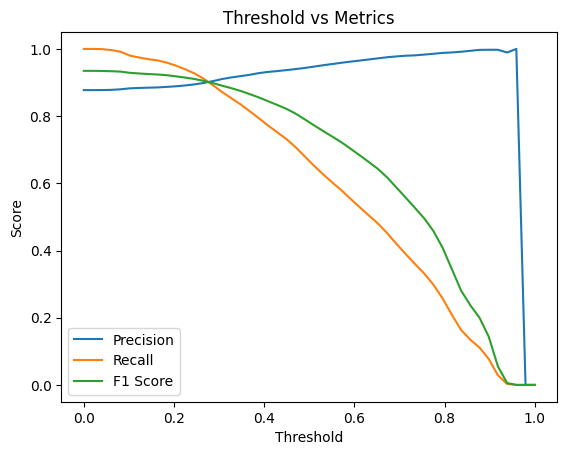

In [74]:
from sklearn.metrics import precision_score, recall_score, f1_score


thresholds = np.linspace(0, 1, 50)

precision_list = []
recall_list = []
f1_list = []

for t in thresholds:
    y_pred_t = (y_probs >= t).astype(int)
    
    precision_list.append(precision_score(y_test, y_pred_t))
    recall_list.append(recall_score(y_test, y_pred_t))
    f1_list.append(f1_score(y_test, y_pred_t))

# Plot
plt.figure()
plt.plot(thresholds, precision_list, label='Precision')
plt.plot(thresholds, recall_list, label='Recall')
plt.plot(thresholds, f1_list, label='F1 Score')

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Metrics")
plt.legend()
plt.show()

In [75]:
for i in range(25,35):
  value = i/100
  threshold = value

  y_pred_new = (y_probs >= threshold).astype(int)

  print(f"threashold {value}")
  print(confusion_matrix(y_test, y_pred_new))
  print("\n", classification_report(y_test, y_pred_new))

threashold 0.25
[[ 2126  7216]
 [ 5092 61788]]

               precision    recall  f1-score   support

           0       0.29      0.23      0.26      9342
           1       0.90      0.92      0.91     66880

    accuracy                           0.84     76222
   macro avg       0.59      0.58      0.58     76222
weighted avg       0.82      0.84      0.83     76222

threashold 0.26
[[ 2347  6995]
 [ 5601 61279]]

               precision    recall  f1-score   support

           0       0.30      0.25      0.27      9342
           1       0.90      0.92      0.91     66880

    accuracy                           0.83     76222
   macro avg       0.60      0.58      0.59     76222
weighted avg       0.82      0.83      0.83     76222

threashold 0.27
[[ 2582  6760]
 [ 6188 60692]]

               precision    recall  f1-score   support

           0       0.29      0.28      0.29      9342
           1       0.90      0.91      0.90     66880

    accuracy                       

final threshold choosen 0.27

### RANDOM FOREST

In [76]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_sm, y_train_sm)

RandomForestClassifier(max_depth=10, n_jobs=-1, random_state=42)

In [77]:
y_probs_rf = rf_model.predict_proba(X_test)[:, 1]

In [78]:
for i in range(25,35):
  value = i/100
  threshold = value
  y_pred_rf = (y_probs_rf >= threshold).astype(int)

  print(f"threshold {threshold}")
  print(confusion_matrix(y_test, y_pred_rf))
  print("\n", classification_report(y_test, y_pred_rf))

threshold 0.25
[[ 2844  6498]
 [ 6302 60578]]

               precision    recall  f1-score   support

           0       0.31      0.30      0.31      9342
           1       0.90      0.91      0.90     66880

    accuracy                           0.83     76222
   macro avg       0.61      0.61      0.61     76222
weighted avg       0.83      0.83      0.83     76222

threshold 0.26
[[ 2997  6345]
 [ 6725 60155]]

               precision    recall  f1-score   support

           0       0.31      0.32      0.31      9342
           1       0.90      0.90      0.90     66880

    accuracy                           0.83     76222
   macro avg       0.61      0.61      0.61     76222
weighted avg       0.83      0.83      0.83     76222

threshold 0.27
[[ 3150  6192]
 [ 7142 59738]]

               precision    recall  f1-score   support

           0       0.31      0.34      0.32      9342
           1       0.91      0.89      0.90     66880

    accuracy                          

### XGBOOST

In [79]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight=1  # already handled by SMOTE
)

xgb_model.fit(X_train_sm, y_train_sm)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, random_state=42, ...)

In [80]:
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [81]:
for i in range(20,51):
  value = i/100
  threshold = value
  y_pred_xgb = (y_probs_xgb >= threshold).astype(int)

  print(f"threshold {threshold}")
  print(confusion_matrix(y_test, y_pred_xgb))
  print(classification_report(y_test, y_pred_xgb))

threshold 0.2
[[  623  8719]
 [ 1049 65831]]
              precision    recall  f1-score   support

           0       0.37      0.07      0.11      9342
           1       0.88      0.98      0.93     66880

    accuracy                           0.87     76222
   macro avg       0.63      0.53      0.52     76222
weighted avg       0.82      0.87      0.83     76222

threshold 0.21
[[  843  8499]
 [ 1455 65425]]
              precision    recall  f1-score   support

           0       0.37      0.09      0.14      9342
           1       0.89      0.98      0.93     66880

    accuracy                           0.87     76222
   macro avg       0.63      0.53      0.54     76222
weighted avg       0.82      0.87      0.83     76222

threshold 0.22
[[ 1062  8280]
 [ 1941 64939]]
              precision    recall  f1-score   support

           0       0.35      0.11      0.17      9342
           1       0.89      0.97      0.93     66880

    accuracy                           0.87  